In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# baseline for now
#     pre: 20
#     post: 250

"""
    record: Index of the trigger record 
    peak_idx: Sample index of the pulse maximum within the full trigger record.
    anchor_idx: Reference point used to define the window center (could be: equal to peak_idx, constant-fraction crossing, leading-edge threshold crossing)
    lo, hi:Window bounds inside the full trigger record - wfs[record, lo:hi]
    amp:Peak amplitude (after baseline subtraction)
    sigma: Noise RMS estimated from the baseline region of this record.
    snr: Signal-to-noise ratio (snr = amp / sigma)
    rise_samples: Rise time measured in number of samples (time between 10% and 90% of peak)
        - Noise spikes → very short rise
        - Pileup → distorted rise
    fwhm_samples: Measures pulse width at 50% amplitude - Broader pulses → more slow component → neutron-like(careful: pileup can make pulses larger)
    q_total: Total integrated charge inside the window.
    q_tail: Charge integrated only in the tail region
    ttr:q_tail / q_total
    is_pileup: true if: secondary peak detected, abnormal rising structure or other pileup criteria met
    baseline_tail: Mean baseline value measured from the tail region of the full trigger
    sigma_tail: RMS of the baseline region
        - This is likely the same quantity as sigma but measured from the tail slice.
            Use this to:
                •	reject noisy triggers
                •	dynamically scale peak threshold
    drift_ptp: Peak-to-peak variation in the baseline region Measures slow baseline drift across the record.
        Large values indicate:
                •	baseline instability
                •	large pickup noise
                •	saturation recovery
    drift_flag: Boolean flag set if drift_ptp exceeds threshold
    is_saturated: ADCsat
"""


'\n    record: Index of the trigger record \n    peak_idx: Sample index of the pulse maximum within the full trigger record.\n    anchor_idx: Reference point used to define the window center (could be: equal to peak_idx, constant-fraction crossing, leading-edge threshold crossing)\n    lo, hi:Window bounds inside the full trigger record - wfs[record, lo:hi]\n    amp:Peak amplitude (after baseline subtraction)\n    sigma: Noise RMS estimated from the baseline region of this record.\n    snr: Signal-to-noise ratio (snr = amp / sigma)\n    rise_samples: Rise time measured in number of samples (time between 10% and 90% of peak)\n        - Noise spikes → very short rise\n        - Pileup → distorted rise\n    fwhm_samples: Measures pulse width at 50% amplitude - Broader pulses → more slow component → neutron-like(careful: pileup can make pulses larger)\n    q_total: Total integrated charge inside the window.\n    q_tail: Charge integrated only in the tail region\n    ttr:q_tail / q_total\n 

In [3]:
def plot_pulses(wfs, sel, Npulses, title='Overlay of pulse window'):
    if Npulses < sel.shape[0]:
        print('print subset of pulses')
        sub = sel.sample(Npulses, random_state=0)
    else:
        sub = sel
    plt.figure()
    for _, row in sub.iterrows():
        rec = int(row["record"])
        lo  = int(row["lo"])
        hi  = int(row["hi"])
        peak = int(row["anchor_idx"])

        seg = wfs[rec, lo:hi]
        x = np.arange(lo, hi) - peak   # peak-aligned overlay
        plt.plot(x, seg, alpha=0.25)

    plt.axvline(0, linestyle="--")
    plt.title(title)
    plt.xlabel("samples relative to window center (peak or cfd)")
    plt.ylabel("ADC")
    plt.show()


In [4]:

wfs = np.load('pns_r25036_chID1_0-99.npz')['wfs']
print(wfs.shape) 

df = pd.read_parquet('pns_r25036_chID1_0-99_v5.parquet')
print(df.shape) 

(32687, 65600)
(504354, 19)


In [5]:
print('% of saturated pulses', df[(df.is_saturated==1)].shape[0]*100/df.shape[0])
print('% of pile-up flagged pulses', df[(df.is_pileup==1)].shape[0]*100/df.shape[0])

% of saturated pulses 1.2667689757590899
% of pile-up flagged pulses 77.67956633634313


In [6]:
df.head()

,record,peak_idx,anchor_idx,lo,hi,amp,sigma,snr,rise_samples,fwhm_samples,q_total,q_tail,ttr,is_pileup,is_saturated,baseline_tail,sigma_tail,drift_ptp,drift_flag
0,0,853,253,233,503,93.00000,8.8956,10.454607,114.0,15.384615,9057.500,0.00,0.0000,1.0,0.0,1564.0,8.8956,9.0,0.0
1,0,888,288,268,538,146.00000,8.8956,16.412608,91.0,37.830763,5813.000,0.00,0.0000,1.0,0.0,1564.0,8.8956,9.0,0.0
2,0,1267,680,660,930,89.33125,8.8956,10.042184,381.0,40.123640,10218.500,0.00,0.0000,0.0,0.0,1564.0,8.8956,9.0,0.0
3,0,2798,2199,2179,2449,108.50375,8.8956,12.197463,264.0,6.625297,7889.835,0.00,0.0000,1.0,0.0,1564.0,8.8956,9.0,0.0
4,0,3781,3774,3754,4024,524.56300,8.8956,58.968816,173.0,64.065579,29777.782,15996.61,0.5372,1.0,0.0,1564.0,8.8956,9.0,0.0


In [7]:
# df_clean = df[(df.is_saturated==0) & (df.is_pileup==0)]
df_clean = df[(df.is_saturated==0) ]
print(df_clean.shape)
print(df_clean.shape[0]*100/df.shape[0])
print(f'removed {df.shape[0]-df_clean.shape[0]} saturated and pile-up pulses')

(497965, 19)
98.73323102424091
removed 6389 saturated and pile-up pulses


In [8]:
# sanity
# sel = df.query('is_saturated==1')
# plot_pulses(wfs, sel, 1000, 'saturated pulses')

In [9]:
# sel = df.query('is_saturated==0')
# plot_pulses(wfs, sel, 5000, 'pulses with no saturation')
# plot_pulses(wfs, sel, 1000000, 'pulses with no saturation') # long

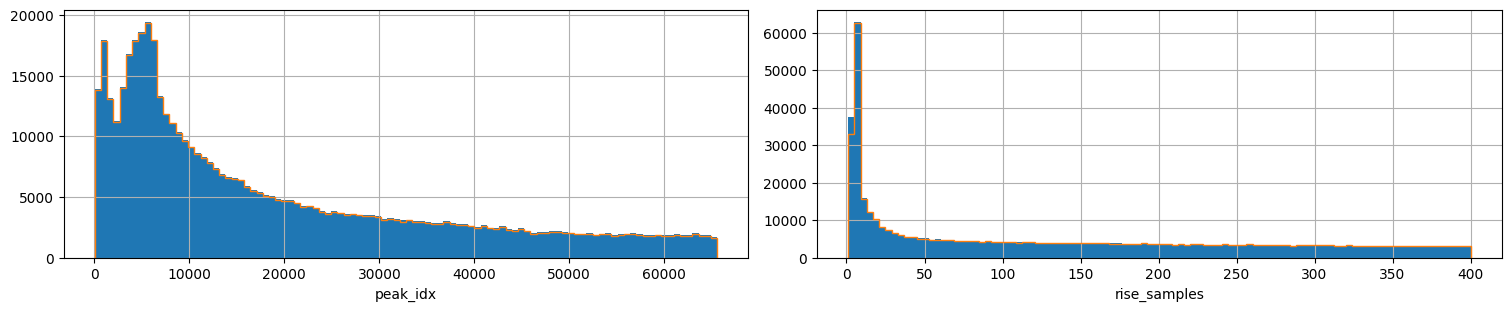

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3), constrained_layout=True)
# peak positions
axs[0].hist(df.peak_idx, bins = 100);
axs[0].hist(df_clean.peak_idx, bins = 100, histtype='step')
axs[0].set_xlabel('peak_idx')

axs[1].hist(df.rise_samples, bins = 100);
axs[1].hist(df_clean.rise_samples, bins = 100, histtype='step')
axs[1].set_xlabel('rise_samples')
for i in range(0, 2):
    axs[i].grid();

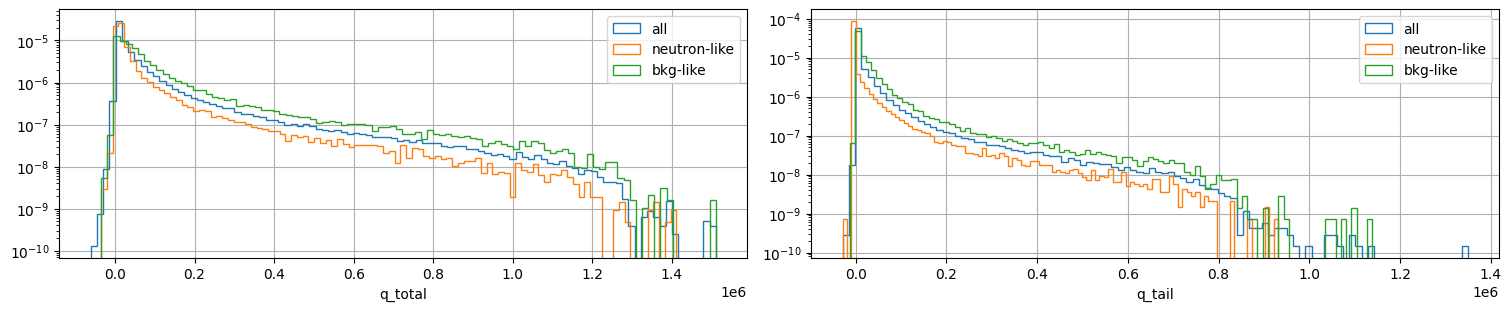

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3), constrained_layout=True)
# peak positions
den=True
axs[0].hist(df_clean.q_total, bins = 100, density=den, histtype='step', label='all')
axs[0].hist(df_clean[df_clean.peak_idx<6000].q_total, bins = 100, density=den, histtype='step', label='neutron-like')
axs[0].hist(df_clean[df_clean.peak_idx>30000].q_total, bins = 100, density=den, histtype='step', label='bkg-like')
axs[0].set_yscale('log')
axs[0].set_xlabel('q_total')

axs[1].hist(df_clean.q_tail, bins = 100, density=den, histtype='step', label='all')
axs[1].hist(df_clean[df_clean.peak_idx<6000].q_tail, bins = 100, density=den, histtype='step', label='neutron-like')
axs[1].hist(df_clean[df_clean.peak_idx>30000].q_tail, bins = 100, density=den, histtype='step', label='bkg-like')
axs[1].set_yscale('log')
axs[1].set_xlabel('q_tail')
for i in range(0, 2):
    axs[i].grid();
    axs[i].legend();

In [12]:
df.columns

Index(['record', 'peak_idx', 'anchor_idx', 'lo', 'hi', 'amp', 'sigma', 'snr',
       'rise_samples', 'fwhm_samples', 'q_total', 'q_tail', 'ttr', 'is_pileup',
       'is_saturated', 'baseline_tail', 'sigma_tail', 'drift_ptp',
       'drift_flag'],
      dtype='object')

print subset of pulses


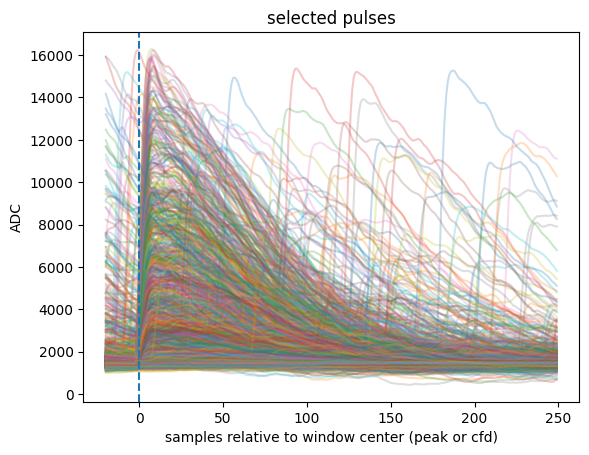

In [13]:
selection = 'drift_flag == 1'
plot_pulses(wfs, df_clean.query(selection), 5000, 'selected pulses')

In [14]:
# # TODO: check what happens for rise_samples < 5
# selection = 'is_saturated==0 and rise_samples < 5'
# plot_pulses(wfs, df.query(selection), 5000, 'selected pulses')

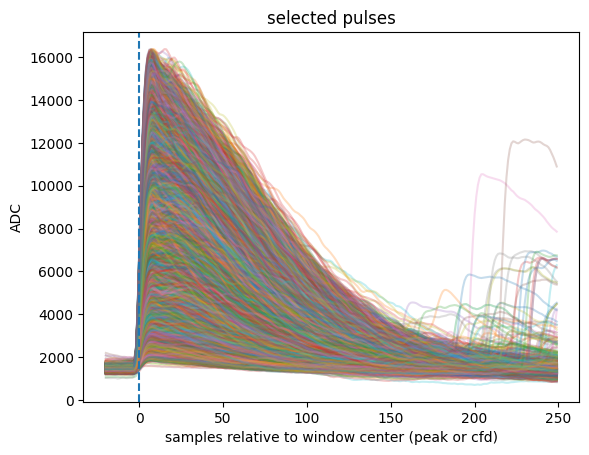

In [15]:
selection = 'is_saturated==0 and is_pileup==0 and ttr > 0 and rise_samples < 7 and snr>50' # and rise_samples < 7  and ttr > 0
df_test = df.query(selection)
plot_pulses(wfs, df_test.query(selection), 100000, 'selected pulses')

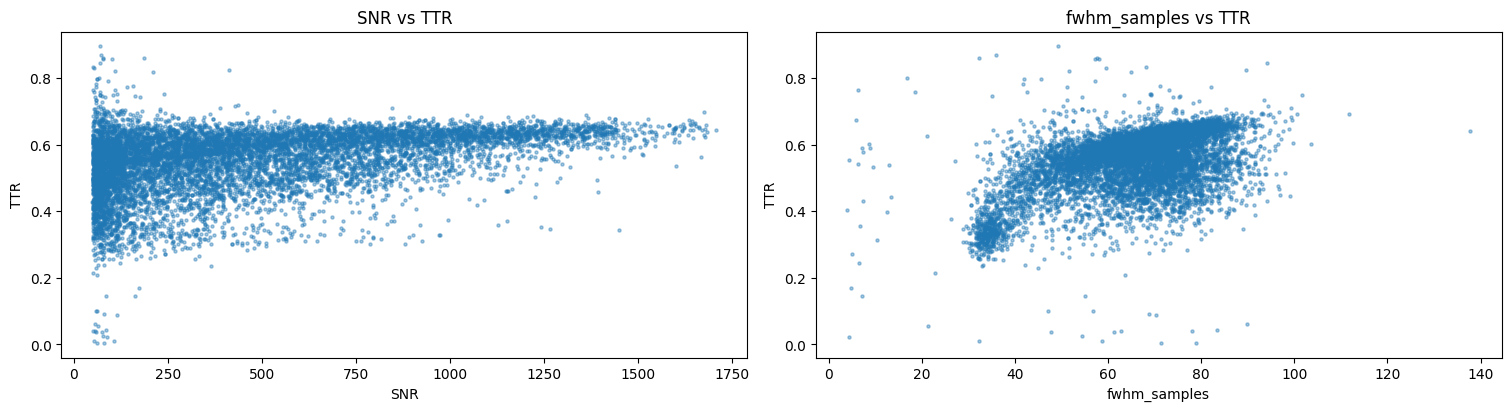

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)


axs[0].scatter(df_test.snr, df_test.ttr,  s=5, alpha=0.4)
axs[0].set_xlabel('SNR')
axs[0].set_ylabel('TTR')
axs[0].set_title("SNR vs TTR")

axs[1].scatter(df_test.fwhm_samples, df_test.ttr,  s=5, alpha=0.4)
axs[1].set_xlabel('fwhm_samples')
axs[1].set_ylabel('TTR')
axs[1].set_title("fwhm_samples vs TTR")
plt.show()

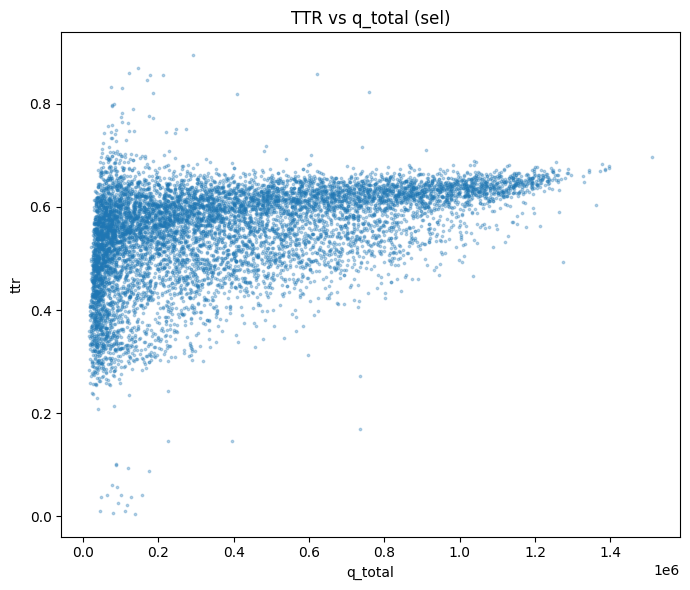

In [17]:
nlike = df_test[(df_test.peak_idx<6000)  & df_test.amp<500 ]
blike = df_test[(df_test.peak_idx>30000) ]
plt.figure(figsize=(7,6))
plt.scatter(
    nlike["q_total"],
    nlike["ttr"],
    s=3,
    alpha=0.3
)
# plt.scatter(
#     blike["q_total"],
#     blike["ttr"],
#     s=3,
#     alpha=0.3
# )
plt.xlabel("q_total")
plt.ylabel("ttr")
plt.title("TTR vs q_total (sel)")
plt.tight_layout()
# plt.ylim(0, 1)
plt.show()

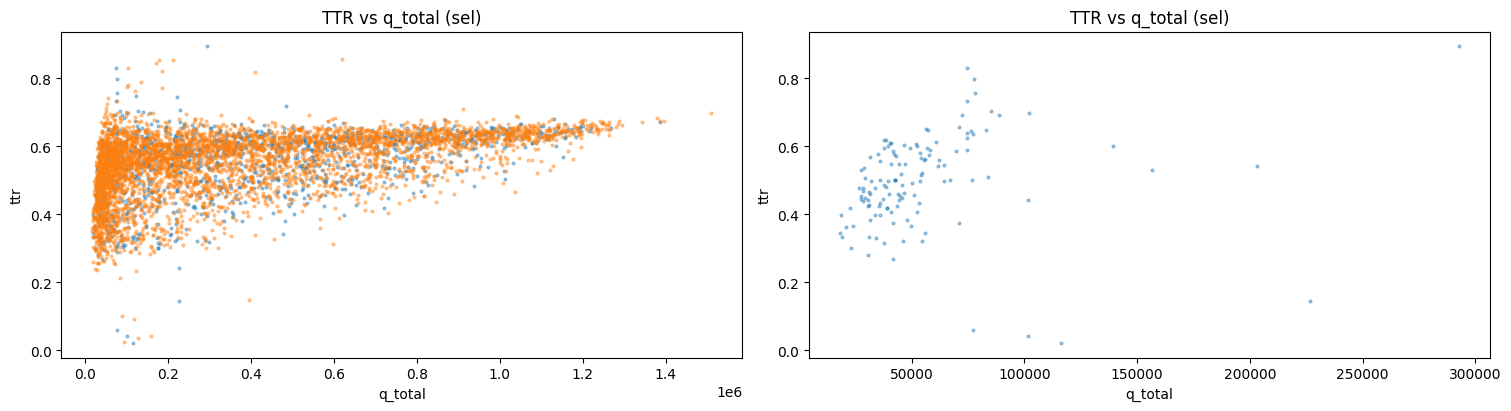

In [27]:


fig, axs = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)

nlike = df_test[(df_test.peak_idx<6000)  ]
blike = df_test[(df_test.peak_idx>30000) ]
axs[0].scatter(nlike.q_total, nlike.ttr,  s=4, alpha=0.4)
axs[0].scatter(blike.q_total, blike.ttr,  s=4, alpha=0.4)
axs[0].set_xlabel('q_total')
axs[0].set_ylabel('ttr')
axs[0].set_title("TTR vs q_total (sel)")

nlike = df_test[(df_test.peak_idx<6000)  & (df_test.amp<1000) ]
blike = df_test[(df_test.peak_idx>30000) ]
axs[1].scatter(nlike.q_total, nlike.ttr,  s=4, alpha=0.4)
# axs[1].scatter(blike.q_total, blike.ttr,  s=4, alpha=0.4)
axs[1].set_xlabel('q_total')
axs[1].set_ylabel('ttr')
axs[1].set_title("TTR vs q_total (sel)")
plt.show()

# nlike = df_test[(df_test.peak_idx<6000) ]
# axs[1].scatter(nlike.q_total, nlike.ttr,  s=4, alpha=0.4)
# nlike = df_test[(df_test.peak_idx<6000)  & (df_test.amp<4000) ]
# axs[1].scatter(nlike.q_total, nlike.ttr,  s=4, alpha=0.4)
# nlike = df_test[(df_test.peak_idx<6000)  & (df_test.fwhm_samples>50) ]
# axs[1].scatter(nlike.q_total, nlike.ttr,  s=4, alpha=0.4)
# # axs[1].scatter(blike.q_total, blike.ttr,  s=4, alpha=0.4)
# axs[1].set_xlabel('q_total')
# axs[1].set_ylabel('ttr')
# axs[1].set_title("TTR vs q_total (sel)")
# plt.show()


In [19]:
# plt.figure(figsize=(7,6))
# plt.scatter(
#     df_test["q_total"],
#     df_test["ttr"],
#     s=3,
#     alpha=0.3
# )
# plt.xlabel("q_total")
# plt.ylabel("ttr")
# plt.title("TTR vs q_total (sel)")
# plt.tight_layout()
# # plt.ylim(0, 1)
# plt.show()

In [20]:
# plt.figure(figsize=(7,6))
# plt.hexbin(
#     df_test["q_total"],
#     df_test["ttr"],
#     gridsize=200,
#     bins='log'
# )

# plt.xlabel("q_total")
# plt.ylabel("ttr")
# plt.title("TTR vs q_total (density)")
# plt.colorbar(label="log10(count)")
# plt.tight_layout()
# plt.show()

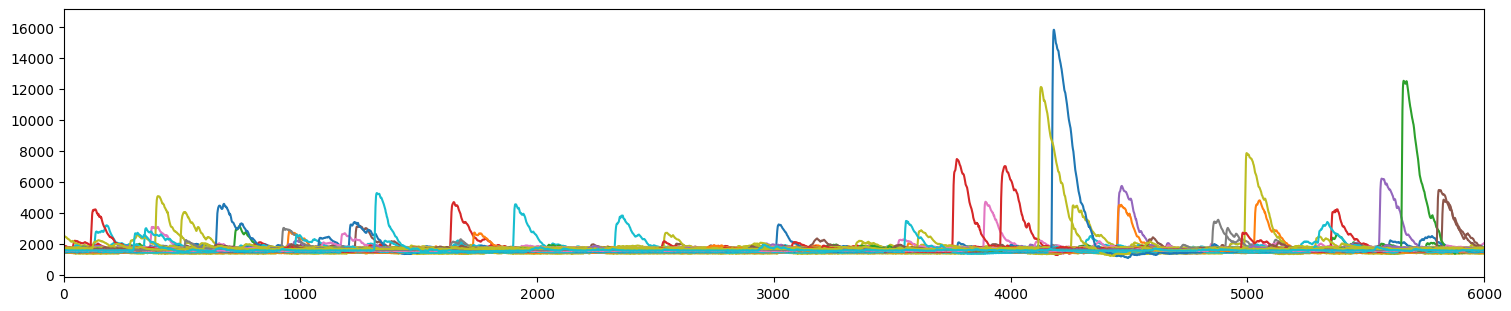

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(15, 3), constrained_layout=True)
for i in range(0, 100):
    axs.plot(wfs[i])
    axs.set_xlim(0, 6000)

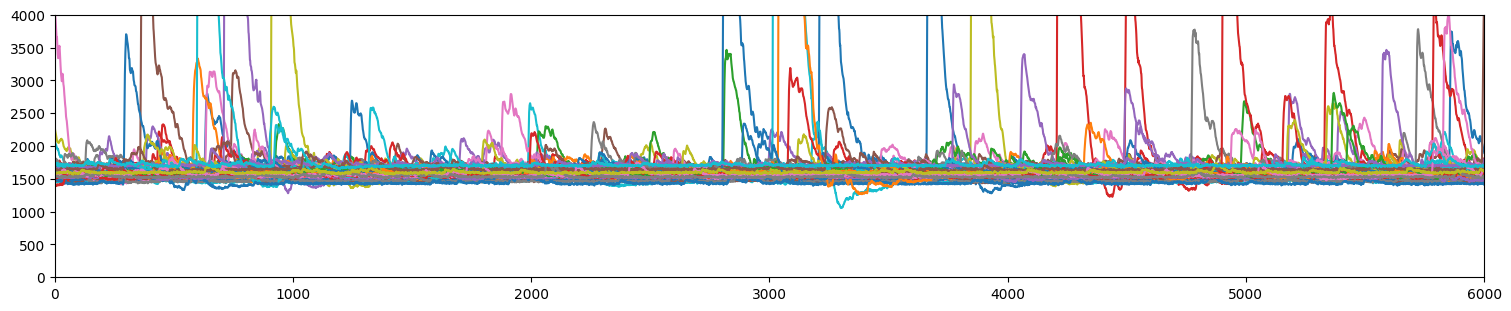

In [22]:
fig, axs = plt.subplots(1, 1, figsize=(15, 3), constrained_layout=True)
for i in range(100, 200):
    axs.plot(wfs[i])
    axs.set_xlim(0, 6000)
    axs.set_ylim(0, 4000)